Assignment Task Overview

Problem Statement
In this project, you will analyze an online retail dataset containing customer transactions, product details, quantities, prices, and purchase dates.
Businesses use such data to understand sales trends, customer behavior, and product performance. However, raw data requires cleaning, transformation, and analysis to generate meaningful insights.
You will build a data analysis pipeline using NumPy, Pandas, Matplotlib, and Seaborn to clean data, perform analysis, visualize patterns, and derive actionable business insights.

Objective
* Clean and preprocess real-world data
* Perform exploratory data analysis (EDA)
* Create new features for analysis
* Visualize trends using charts
* Generate business insights

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1 – Data Import & Setup


1) Load dataset using Pandas


In [ ]:
df = pd.read_excel("Online Retail.xlsx")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


2) Explore structure: head(), tail(), shape, columns


In [7]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [9]:
df.shape

(541909, 8)

In [10]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

3) Convert InvoiceDate to datetime

In [11]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Task 2 – Data Cleaning


1) Handle missing values (remove null CustomerID)


In [12]:
df["CustomerID"].isna().sum()

np.int64(135080)

In [13]:
mean_value = df["CustomerID"].mean()
df["CustomerID"] = df["CustomerID"].fillna(mean_value)

In [14]:
df["CustomerID"].isna().sum()

np.int64(0)

2) Remove duplicates

In [15]:
df.duplicated().sum()

np.int64(5268)

In [16]:
df=df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

3) Fix invalid values (negative quantity, invalid price)

In [18]:
df.loc[df["Quantity"] < 0, "Quantity"] = 0

In [19]:
df.loc[df["UnitPrice"] < 0, "UnitPrice"] = df["UnitPrice"].mean()

# Task 3 – Feature Engineering

1) Create TotalPrice = Quantity × UnitPrice

In [20]:
df["TotalPrice"]=df["Quantity"] * df["UnitPrice"]
df

/tmp/ipykernel_447/2521540360.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TotalPrice"]=df["Quantity"] * df["UnitPrice"]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


2) Extract time features (Year, Month, Day, Hour)

In [21]:
df["Year"]=df["InvoiceDate"].dt.year
df["Month"]=df["InvoiceDate"].dt.month
df["Day"]=df["InvoiceDate"].dt.day
df["Hour"]=df["InvoiceDate"].dt.hour
df

/tmp/ipykernel_447/4183392490.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"]=df["InvoiceDate"].dt.year
/tmp/ipykernel_447/4183392490.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"]=df["InvoiceDate"].dt.month
/tmp/ipykernel_447/4183392490.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,9,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12


3) Create categories (Customer Segment, Order Size, Day Type)

In [22]:
df["CustomerSegment"] = pd.cut(
    df["TotalPrice"],
    bins=[-float("inf"), 100, 500, float("inf")],
    labels=["Low", "Medium", "High"]
)
df

/tmp/ipykernel_447/3601191181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["CustomerSegment"] = pd.cut(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,CustomerSegment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Low
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Low
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,9,12,Low
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9,12,Low
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Low
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Low


In [23]:
df["OrderSize"] = pd.cut(
    df["Quantity"],
    bins=[-float("inf"), 5, 20, float("inf")],
    labels=["Small", "Medium", "Large"]
)
df

/tmp/ipykernel_447/3776314474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["OrderSize"] = pd.cut(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,CustomerSegment,OrderSize
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Low,Medium
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Low,Medium
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,9,12,Low,Medium
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9,12,Low,Medium
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Low,Small
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Low,Small


In [24]:
df["DayType"] = np.where(
    df["InvoiceDate"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)
df

/tmp/ipykernel_447/3748472513.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["DayType"] = np.where(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,CustomerSegment,OrderSize,DayType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Low,Medium,Weekday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium,Weekday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Low,Medium,Weekday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium,Weekday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Low,Medium,Weekday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,9,12,Low,Medium,Weekday
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9,12,Low,Medium,Weekday
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Low,Small,Weekday
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12,Low,Small,Weekday


# Task 4 – Data Exploration

1)Use describe() and dataset overview

In [25]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Year,Month,Day,Hour
count,536641.000000,536641,536641.000000,536641.000000,536641.000000,536641.000000,536641.000000,536641.000000,536641.000000
mean,10.519172,2011-07-04 08:57:06.087421952,4.673900,15282.803924,19.830986,2010.921771,7.544820,15.024640,13.077154
min,0.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000,2010.000000,1.000000,1.000000,6.000000
25%,1.000000,2011-03-28 10:52:00,1.250000,14367.000000,3.750000,2011.000000,5.000000,7.000000,11.000000
50%,3.000000,2011-07-19 14:04:00,2.080000,15287.690570,9.870000,2011.000000,8.000000,15.000000,13.000000
75%,10.000000,2011-10-18 17:05:00,4.130000,16241.000000,17.400000,2011.000000,11.000000,22.000000,15.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,156.036720,NaN,94.856937,1482.757424,268.715742,0.268532,3.508696,8.663351,2.447505


2) Analyze categories (value_counts(), unique())

In [26]:
df["Country"].value_counts()

,count
Country,
United Kingdom,490300
Germany,9480
France,8541
EIRE,8184
Spain,2528
Netherlands,2371
Belgium,2069
Switzerland,1994
Portugal,1510


In [27]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

2) Perform groupby() (country, month, product)

Country-wise Quantity

In [28]:
df.groupby('Country')['Quantity'].sum()

,Quantity
Country,
Australia,84199
Austria,4881
Bahrain,314
Belgium,23237
Brazil,356
Canada,2763
Channel Islands,9485
Cyprus,6340
Czech Republic,671


Month-wise Quantity

In [29]:
df.groupby('Month')['Quantity'].sum()

,Quantity
Month,
1,397030
2,286074
3,384023
4,311314
5,398686
6,393633
7,405473
8,424266
9,574169


# Task 5 – Data Wrangling

1) Aggregate data using groupby()
2) Sort to find the top customers and countries
3) Restructure data if needed

In [30]:
# 1. Aggregate data using groupby()
# Country-wise sales
country_sales = df.groupby("Country")["TotalPrice"].sum()
print("Country-wise Sales:")
print(country_sales.sort_values(ascending=False).head(10))

Country-wise Sales:
Country
United Kingdom    9.001753e+06
Netherlands       2.854463e+05
EIRE              2.831405e+05
Germany           2.286784e+05
France            2.096254e+05
Australia         1.384538e+05
Spain             6.155856e+04
Switzerland       5.706760e+04
Belgium           4.119634e+04
Sweden            3.836783e+04
Name: TotalPrice, dtype: float64


In [31]:
# Customer-wise total spending
customer_sales = (
    df.groupby("CustomerID")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)
print("Top 10 Customers:")
print(customer_sales.head(10))

Top 10 Customers:
CustomerID
15287.69057    1.754911e+06
14646.00000    2.802060e+05
18102.00000    2.596573e+05
17450.00000    1.943908e+05
16446.00000    1.684725e+05
14911.00000    1.437112e+05
12415.00000    1.249145e+05
14156.00000    1.172101e+05
17511.00000    9.106238e+04
16029.00000    8.085084e+04
Name: TotalPrice, dtype: float64


In [32]:
# Country-wise total sales
top_countries = (
    df.groupby("Country")
      .agg(
          Total_Sales=("TotalPrice", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Number_of_Orders=("InvoiceNo", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)
print("Top 10 Countries:")
print(top_countries.head(10))

Top 10 Countries:
                 Total_Sales  Total_Quantity  Number_of_Orders
Country                                                       
United Kingdom  9.001753e+06         4718329             23494
Netherlands     2.854463e+05          200937               101
EIRE            2.831405e+05          147281               360
Germany         2.286784e+05          119156               603
France          2.096254e+05          112061               461
Australia       1.384538e+05           84199                69
Spain           6.155856e+04           27944               105
Switzerland     5.706760e+04           30618                74
Belgium         4.119634e+04           23237               119
Sweden          3.836783e+04           36078                46


In [33]:
# Product-wise sales
product_sales = (
    df.groupby("Description")
      .agg(
          Total_Sales=("TotalPrice", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)
print("Top 10 Products:")
print(product_sales.head(10))

Top 10 Products:
                                    Total_Sales  Total_Quantity
Description                                                    
DOTCOM POSTAGE                        206248.77             708
REGENCY CAKESTAND 3 TIER              174156.54           13862
PAPER CRAFT , LITTLE BIRDIE           168469.60           80995
WHITE HANGING HEART T-LIGHT HOLDER    106236.72           37876
PARTY BUNTING                          99445.23           18287
JUMBO BAG RED RETROSPOT                94159.81           48375
MEDIUM CERAMIC TOP STORAGE JAR         81700.92           78033
POSTAGE                                78101.88            3150
Manual                                 77752.82            6991
RABBIT NIGHT LIGHT                     66870.03           30739


In [34]:
# Create a country summary table
country_summary = (
    df.groupby("Country")
      .agg(
          Total_Sales=("TotalPrice", "sum"),
          Average_Order_Value=("TotalPrice", "mean"),
          Total_Quantity=("Quantity", "sum"),
          Number_of_Customers=("CustomerID", "nunique")
      )
      .reset_index()
)
print(country_summary.head())

     Country  Total_Sales  Average_Order_Value  Total_Quantity  \
0  Australia    138453.81           110.058672           84199   
1    Austria     10198.68            25.433117            4881   
2    Bahrain       754.14            39.691579             314   
3    Belgium     41196.34            19.911232           23237   
4     Brazil      1143.60            35.737500             356   

   Number_of_Customers  
0                    9  
1                   11  
2                    3  
3                   25  
4                    1  


In [35]:
monthly_country_sales = pd.pivot_table(
    df,
    values="TotalPrice",
    index="Country",
    columns="Month",
    aggfunc="sum"
)
print(monthly_country_sales.head())

Month           1         2         3        4         5         6        7   \
Country                                                                        
Australia  9017.71  14695.42  17223.99   771.60  13638.41  25187.77  4964.38   
Austria        NaN    518.36   1708.12   680.78   1249.43      0.00  1191.95   
Bahrain       0.00       NaN       NaN      NaN    548.40       NaN      NaN   
Belgium    1200.20   2181.07   3351.98  1989.48   2732.40   4274.82  2475.57   
Brazil         NaN       NaN       NaN  1143.60       NaN       NaN      NaN   

Month            8        9         10       11       12  
Country                                                   
Australia  22489.20  5106.73  17150.53  7242.72   965.35  
Austria     1516.08      NaN   1043.78  1329.78   960.40  
Bahrain         NaN      NaN       NaN      NaN   205.74  
Belgium     3554.02  4208.02   5685.38  6315.76  3227.64  
Brazil          NaN      NaN       NaN      NaN      NaN  


# Task 6 – Statistical Analysis

1) Analyze Quantity, UnitPrice, TotalPrice
2) Calculate mean, median, and mode
3) Find standard deviation, variance, and percentiles

In [36]:
numeric_columns = ["Quantity", "UnitPrice", "TotalPrice"]
# Mean
mean_values = df[numeric_columns].mean()
# Median
median_values = df[numeric_columns].median()
# Mode
mode_values = df[numeric_columns].mode()
# Standard Deviation
std_values = df[numeric_columns].std()
# Variance
variance_values = df[numeric_columns].var()
# Percentiles
percentiles = df[numeric_columns].quantile([0.25, 0.50, 0.75])
print("========== MEAN ==========")
print(mean_values)
print("\n========== MEDIAN ==========")
print(median_values)
print("\n========== MODE ==========")
print(mode_values)
print("\n========== STANDARD DEVIATION ==========")
print(std_values)
print("\n========== VARIANCE ==========")
print(variance_values)
print("\n========== PERCENTILES ==========")
print(percentiles)

========== MEAN ==========
Quantity      10.519172
UnitPrice      4.673900
TotalPrice    19.830986
dtype: float64

========== MEDIAN ==========
Quantity      3.00
UnitPrice     2.08
TotalPrice    9.87
dtype: float64

========== MODE ==========
   Quantity  UnitPrice  TotalPrice
0         1       1.25        15.0

========== STANDARD DEVIATION ==========
Quantity      156.036720
UnitPrice      94.856937
TotalPrice    268.715742
dtype: float64

========== VARIANCE ==========
Quantity      24347.457974
UnitPrice      8997.838562
TotalPrice    72208.150056
dtype: float64

========== PERCENTILES ==========
      Quantity  UnitPrice  TotalPrice
0.25       1.0       1.25        3.75
0.50       3.0       2.08        9.87
0.75      10.0       4.13       17.40


# Task 7 – Data Visualization

Line chart

Monthly Sales Trend


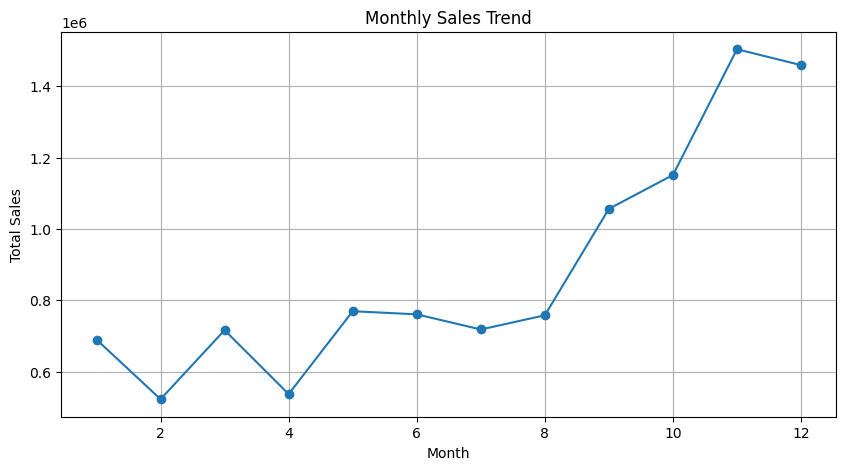

In [37]:
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

 Bar chart

 Top 10 Countries

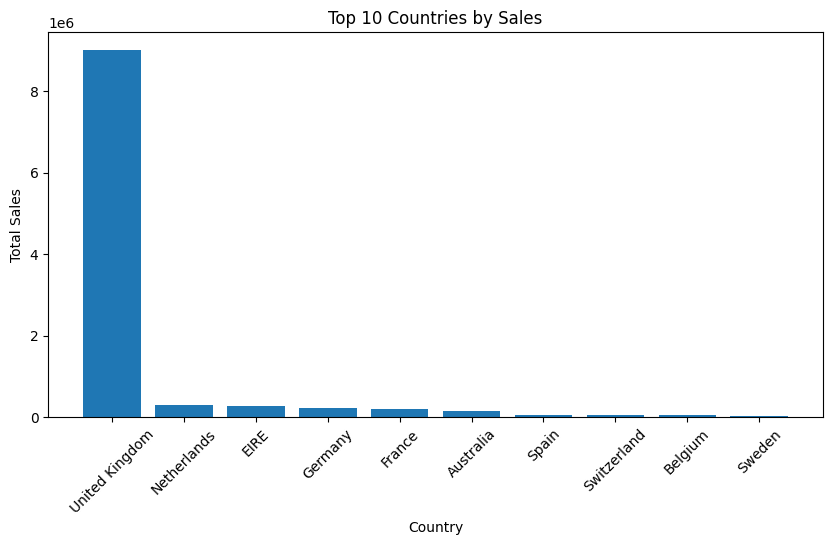

In [38]:
top_10_countries = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(10, 5))
plt.bar(
    top_10_countries.index,
    top_10_countries.values
)
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

Histogram

production of Country


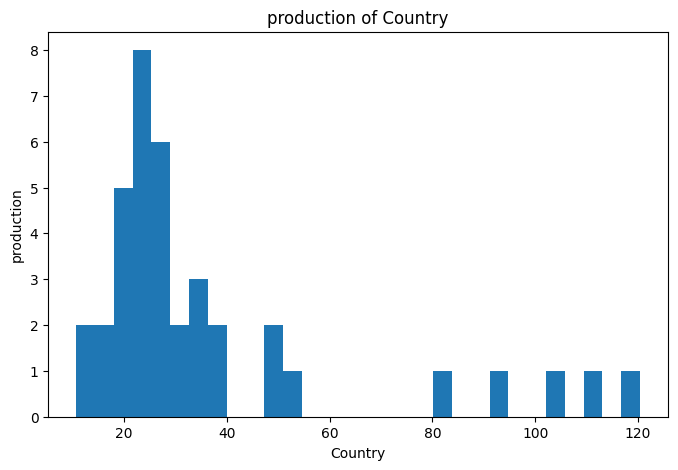

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(
    df.groupby("Country")["TotalPrice"].mean(),
    bins=30
)
plt.title("production of Country")
plt.xlabel("Country")
plt.ylabel("production")
plt.show()

Box plot

TotalPrice Distribution

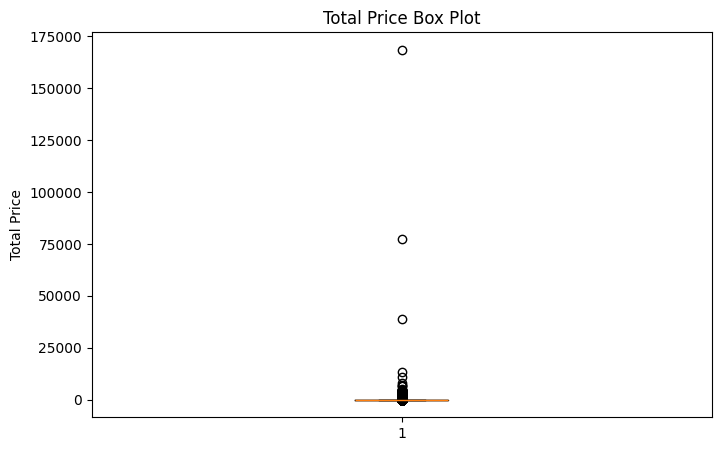

In [40]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["TotalPrice"])
plt.title("Total Price Box Plot")
plt.ylabel("Total Price")
plt.show()

Count plot

Customer Segment

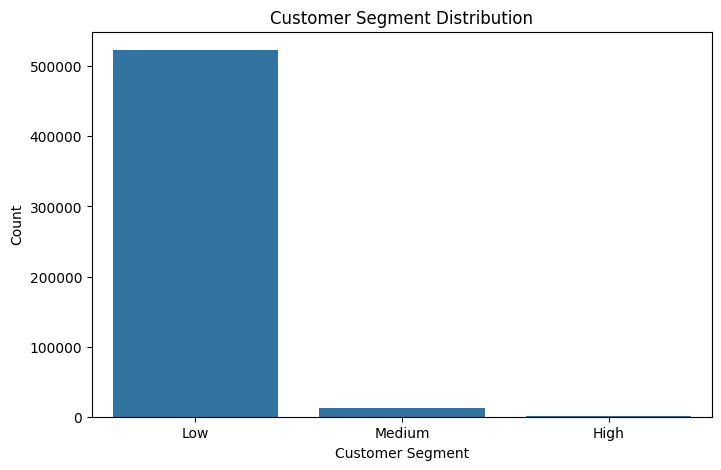

In [41]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="CustomerSegment"
)
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.show()

Violin plot

TotalPrice by Day Type

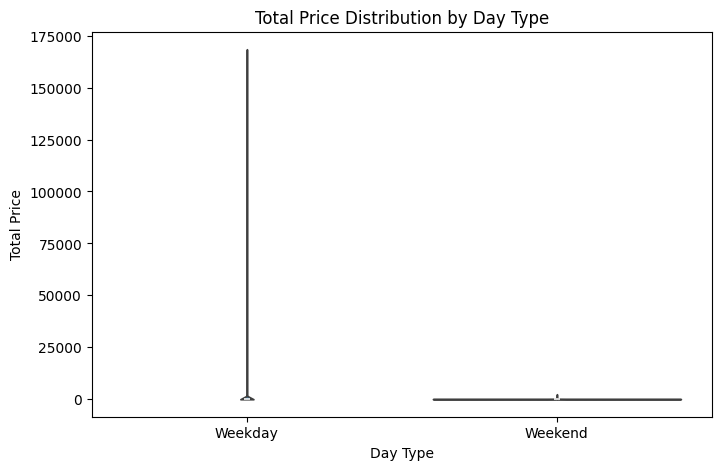

In [42]:
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df,
    x="DayType",
    y="TotalPrice"
)
plt.title("Total Price Distribution by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Total Price")
plt.show()

Heatmap

Correlation



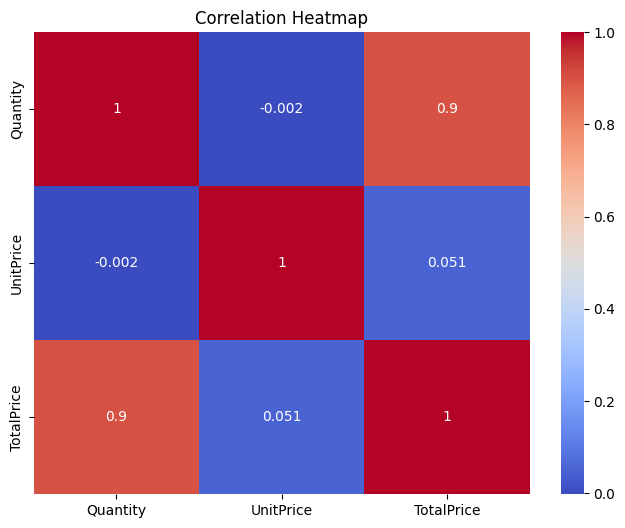

In [43]:
correlation = df[
    ["Quantity", "UnitPrice", "TotalPrice"]
].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

Pair plot

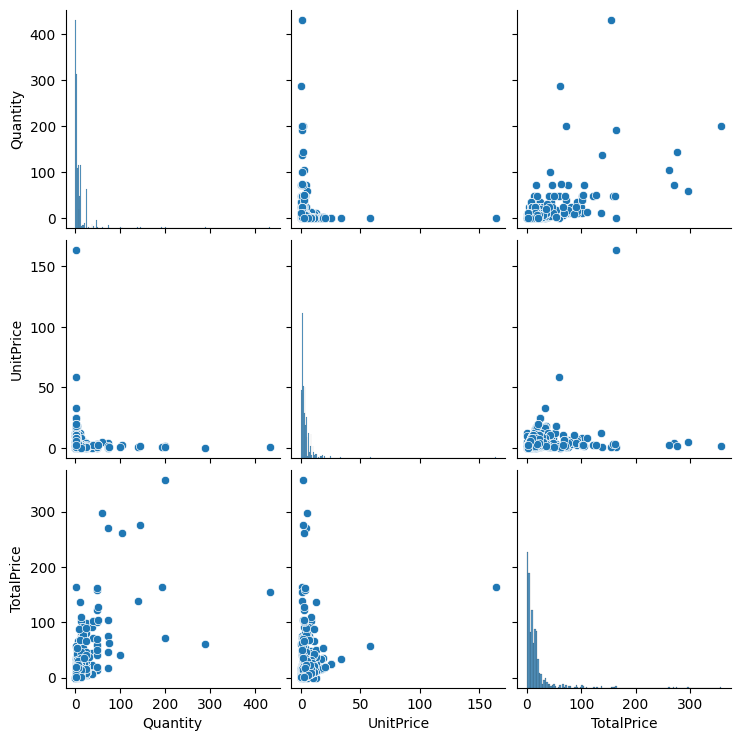

In [44]:
sns.pairplot(
    df[
        ["Quantity", "UnitPrice", "TotalPrice"]
    ].sample(1000)
)
plt.show()

# Task 8 – Business Insights

##Identify:

Top country

In [45]:
top_country = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .idxmax()
)
print("Top Country:", top_country)

Top Country: United Kingdom


Best Sales Month

In [46]:
best_month = (
    df.groupby("Month")["TotalPrice"]
      .sum()
      .idxmax()
)
print("Best Sales Month:", best_month)

Best Sales Month: 11


Peak sales time

In [47]:
peak_hour = (
    df.groupby("Hour")["TotalPrice"]
      .sum()
      .idxmax()
)
print("Peak Sales Hour:", peak_hour)

Peak Sales Hour: 10


##Analyze:

Customer behavior

In [48]:
customer_behavior = df.groupby(
    "CustomerID"
).agg(
    TotalSpent=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfOrders=("InvoiceNo", "nunique")
)
print(customer_behavior.describe())

         TotalSpent  TotalQuantity  NumberOfOrders
count  4.373000e+03    4373.000000     4373.000000
mean   2.433597e+03    1290.880174        5.922708
std    2.797760e+04    8808.208058       56.798813
min    0.000000e+00       0.000000        1.000000
25%    3.022000e+02     155.000000        1.000000
50%    6.594600e+02     372.000000        3.000000
75%    1.647480e+03     983.000000        5.000000
max    1.754911e+06  479133.000000     3710.000000


High-value customers

In [49]:
high_value_customers = (
    df.groupby("CustomerID")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print("Top 10 High-Value Customers:")
print(high_value_customers)

Top 10 High-Value Customers:
CustomerID
15287.69057    1.754911e+06
14646.00000    2.802060e+05
18102.00000    2.596573e+05
17450.00000    1.943908e+05
16446.00000    1.684725e+05
14911.00000    1.437112e+05
12415.00000    1.249145e+05
14156.00000    1.172101e+05
17511.00000    9.106238e+04
16029.00000    8.085084e+04
Name: TotalPrice, dtype: float64


Top products

In [50]:
top_products = (
    df.groupby("Description")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print("Top 10 Products:")
print(top_products)

Top 10 Products:
Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: TotalPrice, dtype: float64
